<a href="https://colab.research.google.com/github/Koushik23R/groundwater-ai/blob/main/notebooks/05_baseline_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Why a Baseline Model?

Before training sophisticated algorithms like Random Forest or XGBoost, we first answer:

Can a very simple prediction already perform well?

For time-series forecasting, the most common baseline is:

$\hat{y}_t = y_{t-1}$

Meaning,

The next groundwater level is assumed to be the same as the previous observation (Lag_1).

Since we already created Lag_1 in Notebook 4, this becomes our baseline prediction.

Every machine learning model in later notebooks should perform better than this baseline.

# 5.1 Import Required Libraries

This notebook develops a baseline forecasting model for groundwater level prediction.

The feature-engineered dataset created in Notebook 4 is loaded, followed by preparation of training and testing datasets. A persistence (naïve) forecasting model is implemented as the baseline against which future machine learning models will be compared.

In [1]:
import pandas as pd
import numpy as np

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

print("Libraries imported successfully.")

Libraries imported successfully.


## 5.2 Load Feature Engineered Dataset

The feature-engineered dataset generated in Notebook 4 is loaded for model development.

This dataset contains temporal, lag, rolling, cyclical, and station encoding features required for groundwater level forecasting.

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

project_root = Path.cwd().resolve()
engineered_path = None
for candidate in [project_root, project_root.parent]:
    path = candidate / "data" / "processed" / "groundwater_feature_engineered.csv"
    if path.exists():
        engineered_path = path
        break

if engineered_path is None:
    raise FileNotFoundError("groundwater_feature_engineered.csv not found under data/processed/.")

# Load engineered dataset
df = pd.read_csv(engineered_path, parse_dates=["Data Acquisition Time"])

print("Dataset loaded successfully.")
print("Shape:", df.shape)
print("Stations:", df["Station"].nunique())
print("Source:", engineered_path)

df.head()


Dataset loaded successfully.
Shape: (69404, 25)
Stations: 18
Source: /workspaces/groundwater-ai/data/processed/groundwater_feature_engineered.csv


,Station,Data Acquisition Time,Latitude,Longitude,Groundwater Level Telemetry 6 Hourly (meter),RL_MSL,time_diff,Year,Month,Day,...,Lag_1,Lag_4,Lag_28,RollingMean_4,RollingStd_4,Hour_sin,Hour_cos,Month_sin,Month_cos,Station_ID
0,Adakamaranahalli,2021-10-06 00:00:00,13.07,77.45,-22.50,849.0,1 days 06:00:00,2021,10,6,...,-22.71,-22.34,-22.51,-22.8625,0.419235,0.000000e+00,1.000000e+00,-1.0,-1.836970e-16,0
1,Adakamaranahalli,2021-10-06 06:00:00,13.07,77.45,-22.83,849.0,0 days 06:00:00,2021,10,6,...,-22.50,-23.16,-22.87,-22.9025,0.355563,1.000000e+00,6.123234e-17,-1.0,-1.836970e-16,0
2,Adakamaranahalli,2021-10-06 12:00:00,13.07,77.45,-22.88,849.0,0 days 06:00:00,2021,10,6,...,-22.83,-23.24,-23.23,-22.8200,0.311448,1.224647e-16,-1.000000e+00,-1.0,-1.836970e-16,0
3,Adakamaranahalli,2021-10-06 18:00:00,13.07,77.45,-22.52,849.0,0 days 06:00:00,2021,10,6,...,-22.88,-22.71,-22.66,-22.7300,0.169115,-1.000000e+00,-1.836970e-16,-1.0,-1.836970e-16,0
4,Adakamaranahalli,2021-10-07 00:00:00,13.07,77.45,-22.35,849.0,0 days 06:00:00,2021,10,7,...,-22.52,-22.50,-22.46,-22.6825,0.200395,0.000000e+00,1.000000e+00,-1.0,-1.836970e-16,0


## 5.3 Dataset Overview

Before training the baseline model, the feature-engineered dataset is inspected to verify its structure, feature availability, and data types.

This step confirms that the dataset is ready for model development and that no missing values remain.

In [3]:
print("=" * 60)
print("Dataset Information")
print("=" * 60)

print("\nShape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Information

Shape: (69404, 25)

Columns:
['Station', 'Data Acquisition Time', 'Latitude', 'Longitude', 'Groundwater Level Telemetry 6 Hourly (meter)', 'RL_MSL', 'time_diff', 'Year', 'Month', 'Day', 'Hour', 'DayOfWeek', 'WeekOfYear', 'Quarter', 'IsWeekend', 'Lag_1', 'Lag_4', 'Lag_28', 'RollingMean_4', 'RollingStd_4', 'Hour_sin', 'Hour_cos', 'Month_sin', 'Month_cos', 'Station_ID']

Data Types:
Station                                                    str
Data Acquisition Time                           datetime64[us]
Latitude                                               float64
Longitude                                              float64
Groundwater Level Telemetry 6 Hourly (meter)           float64
RL_MSL                                                 float64
time_diff                                                  str
Year                                                     int64
Month                                                    int64
Day                          

## 5.4 Define Features and Target

The target variable is the groundwater level measured every six hours.

All engineered numerical variables are used as predictor features, while identifier columns and the target variable itself are excluded.

In [4]:
target = "Groundwater Level Telemetry 6 Hourly (meter)"

feature_columns = [
    col for col in df.columns
    if col not in [
        target,
        "Station",
        "Data Acquisition Time",
        "time_diff"          # Drop this
    ]
]

X = df[feature_columns]
y = df[target]

print("Number of features:", X.shape[1])
print(X.columns.tolist())

Number of features: 21
['Latitude', 'Longitude', 'RL_MSL', 'Year', 'Month', 'Day', 'Hour', 'DayOfWeek', 'WeekOfYear', 'Quarter', 'IsWeekend', 'Lag_1', 'Lag_4', 'Lag_28', 'RollingMean_4', 'RollingStd_4', 'Hour_sin', 'Hour_cos', 'Month_sin', 'Month_cos', 'Station_ID']


## 5.5 Time-Based Train-Test Split

To simulate real-world forecasting, the dataset is split chronologically rather than randomly.

The earliest 80% of observations are used for training, while the most recent 20% are reserved for testing. This prevents information leakage from future observations into the training data.

In [5]:
# Ensure chronological ordering
df = df.sort_values("Data Acquisition Time").reset_index(drop=True)

# Recreate X and y after sorting
X = df[feature_columns]
y = df[target]

# 80-20 chronological split
split_index = int(len(df) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

print("\nTraining period:")
print(df.iloc[0]["Data Acquisition Time"], "to",
      df.iloc[split_index-1]["Data Acquisition Time"])

print("\nTesting period:")
print(df.iloc[split_index]["Data Acquisition Time"], "to",
      df.iloc[-1]["Data Acquisition Time"])

Training samples: 55523
Testing samples : 13881

Training period:
2021-10-06 00:00:00 to 2025-03-05 00:00:00

Testing period:
2025-03-05 00:00:00 to 2025-12-30 18:00:00


## Memory Usage Analysis

Before training the baseline model, it is useful to examine the dataset's memory footprint.

This analysis helps us:

- Understand how much RAM the dataset occupies during model training.
- Identify columns that consume the most memory (especially object or string columns).
- Verify whether the dataset can be processed efficiently on a standard computer without additional memory optimization.
- Document the computational requirements of the project for reproducibility.

Since machine learning models operate primarily on numerical feature matrices, this step also confirms that the engineered dataset is lightweight and suitable for training baseline and advanced models.

In [6]:
# Dataset memory usage
print(df.memory_usage(deep=True))

# Total memory usage in MB
print(f"\nTotal memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Index                                               132
Station                                         4338299
Data Acquisition Time                            555232
Latitude                                         555232
Longitude                                        555232
Groundwater Level Telemetry 6 Hourly (meter)     555232
RL_MSL                                           555232
time_diff                                       4441926
Year                                             555232
Month                                            555232
Day                                              555232
Hour                                             555232
DayOfWeek                                        555232
WeekOfYear                                       555232
Quarter                                          555232
IsWeekend                                        555232
Lag_1                                            555232
Lag_4                                           


Total memory usage: 20.55 MB

## Baseline Model: Linear Regression

As a first benchmark, we train a simple Linear Regression model.

Linear Regression is computationally efficient and provides a useful baseline against which more advanced machine learning models can later be compared.

Although groundwater levels exhibit nonlinear temporal behavior, a linear model helps determine whether the engineered features alone capture sufficient predictive information.

In [7]:
from sklearn.linear_model import LinearRegression

# Initialize model
lr_model = LinearRegression()

# Train
lr_model.fit(X_train, y_train)

print("✅ Linear Regression model trained successfully.")

✅ Linear Regression model trained successfully.


## Generate Predictions

After training the baseline model, predictions are generated for both the training and testing datasets.

These predictions will be used to evaluate the model's performance and identify potential overfitting or underfitting.

In [8]:
# Predictions
train_pred = lr_model.predict(X_train)
test_pred = lr_model.predict(X_test)

print("Training predictions shape:", train_pred.shape)
print("Testing predictions shape :", test_pred.shape)

Training predictions shape: (55523,)
Testing predictions shape : (13881,)


## Model Performance Evaluation

The baseline model is evaluated using standard regression metrics.

The following metrics are computed:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Coefficient of Determination (R²)

These metrics provide a quantitative assessment of prediction accuracy and establish the baseline performance for comparison with advanced machine learning models.

In [9]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Training metrics
train_mae = mean_absolute_error(y_train, train_pred)
train_rmse = mean_squared_error(y_train, train_pred) ** 0.5
train_r2 = r2_score(y_train, train_pred)

# Testing metrics
test_mae = mean_absolute_error(y_test, test_pred)
test_rmse = mean_squared_error(y_test, test_pred) ** 0.5
test_r2 = r2_score(y_test, test_pred)

print("="*50)
print("Linear Regression Performance")
print("="*50)

print(f"Training MAE : {train_mae:.4f}")
print(f"Training RMSE: {train_rmse:.4f}")
print(f"Training R²  : {train_r2:.4f}")

print()

print(f"Testing MAE : {test_mae:.4f}")
print(f"Testing RMSE: {test_rmse:.4f}")
print(f"Testing R²  : {test_r2:.4f}")

Linear Regression Performance
Training MAE : 2.7983
Training RMSE: 9.6692
Training R²  : 0.9335

Testing MAE : 3.4003
Testing RMSE: 10.3652
Testing R²  : 0.9586


## Actual vs Predicted Groundwater Levels

A scatter plot comparing actual and predicted groundwater levels provides a visual assessment of model performance.

If the model performs well, the predicted values should closely follow the diagonal reference line, indicating strong agreement between observations and predictions.

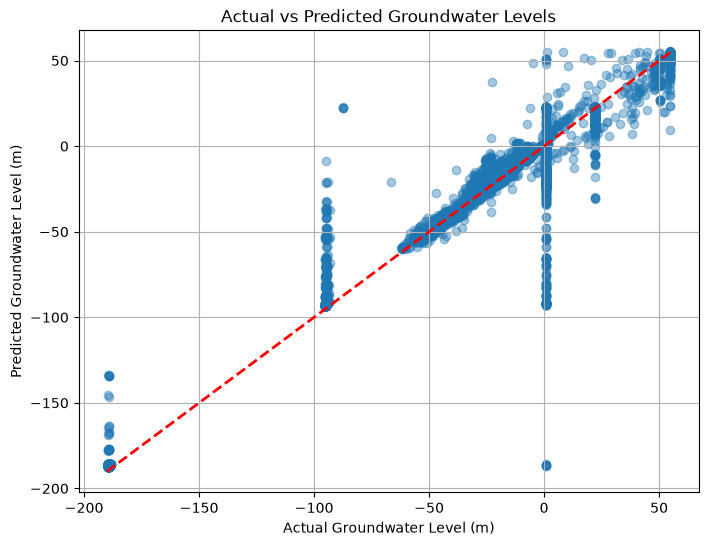

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    test_pred,
    alpha=0.4
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Groundwater Level (m)")
plt.ylabel("Predicted Groundwater Level (m)")
plt.title("Actual vs Predicted Groundwater Levels")

plt.grid(True)

plt.show()

The scatter plot demonstrates a strong agreement between observed and predicted groundwater levels, confirming that the engineered temporal and lag-based features provide substantial predictive information.

## Residual Analysis

Residuals represent the difference between observed and predicted groundwater levels.

A well-performing regression model should produce residuals that are randomly distributed around zero without systematic patterns.

Residual analysis helps identify bias, heteroscedasticity, and regions where prediction errors become larger.

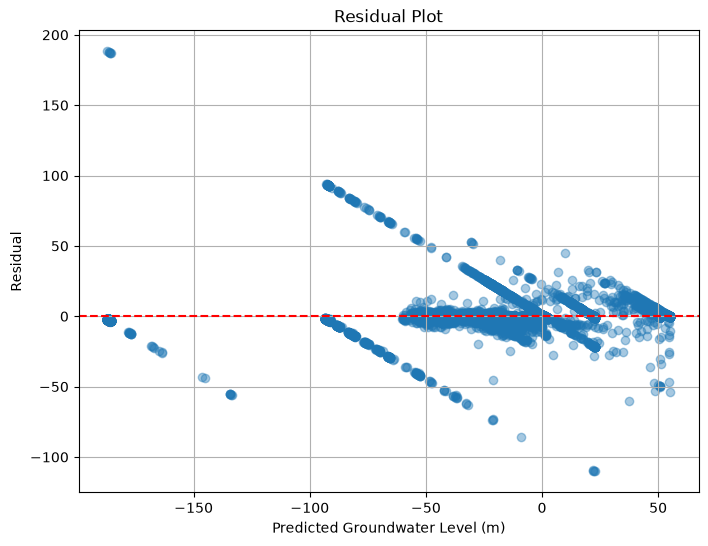

In [11]:
residuals = y_test - test_pred

plt.figure(figsize=(8,6))

plt.scatter(
    test_pred,
    residuals,
    alpha=0.4
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted Groundwater Level (m)")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.grid(True)

plt.show()

#Observations

Most residuals are concentrated around zero.
There is no strong systematic upward or downward trend.
Larger residuals mainly occur for extreme groundwater values.

**This suggests:**

The model is largely unbiased.
Most prediction errors are relatively small.
Extreme groundwater fluctuations remain challenging for a simple linear model.

These difficult observations motivate trying nonlinear models such as Random Forest and XGBoost in the following notebooks.

## Save Baseline Performance

The evaluation metrics of the baseline model are stored in a structured table.

This table will be extended in later notebooks to compare the performance of multiple machine learning models.

In [12]:
baseline_results = pd.DataFrame({
    "Model": ["Linear Regression"],
    "MAE": [test_mae],
    "RMSE": [test_rmse],
    "R2": [test_r2]
})

baseline_results

,Model,MAE,RMSE,R2
0,Linear Regression,3.400291,10.365231,0.958608


# Conclusion

In this notebook, a baseline Linear Regression model was developed to establish an initial benchmark for groundwater level prediction.

The feature-engineered dataset generated in the previous notebook was used to train and evaluate the model using a chronological train-test split. Model performance was assessed using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the coefficient of determination (R²).

The baseline model achieved:

- **MAE:** 3.40 meters
- **RMSE:** 10.37 meters
- **R² Score:** 0.9586

The Actual vs Predicted plot demonstrated a strong agreement between observed and predicted groundwater levels, while the residual analysis indicated that prediction errors were generally centered around zero. Larger errors were primarily associated with extreme groundwater observations, suggesting that complex nonlinear relationships may still exist within the data.

Overall, the Linear Regression model provides a strong baseline and establishes a performance benchmark for subsequent machine learning models.

In the next notebook, advanced ensemble learning algorithms such as **Random Forest Regression** will be developed and evaluated to determine whether nonlinear models can further improve groundwater level forecasting accuracy.